In [1]:
import importlib

import experiment
import experiment.config
import experiment.data
import experiment.rolling_forecast.runner

importlib.reload(experiment.config)
importlib.reload(experiment.data)
importlib.reload(experiment.rolling_forecast.runner)
importlib.reload(experiment)

from experiment import DatasetBuilder, ModelSpec, RollingForecastRunner, RunConfig


In [ ]:
CSV_PATH = './data/33101.csv'
UNIQUE_ID = 'ZJ'

INPUT_SIZE = 96
HORIZON = 7
SPLIT_RATIO = (7, 1, 2)
SLIDING_STEP_SIZE = 1

REMOVE_LAST_MONTH = True
# REMOVE_LAST_MONTH = False

USE_HIST_EXOG = True
# USE_HIST_EXOG = False

USE_FUTR_EXOG = True
# USE_FUTR_EXOG = False

SAVE_PLOTS = True
RANDOM_SEED = 2026
EARLY_STOP_PATIENCE_STEPS = 7
VAL_CHECK_STEPS = 5
ML_EARLY_STOPPING_ROUNDS = 20
# Neural training/validation loss
# Options:
# - 'MAE'
# - 'MSE'
# - 'RMSE'
# - 'MAPE'
# - 'SMAPE'
# - 'HuberLoss'   optional params: {'delta': 1.0}
# - 'TukeyLoss'   optional params: {'c': 4.685, 'normalize': True}
# - 'MASE'        required params: {'seasonality': 7}
NEURAL_LOSS_NAME = 'MSE'
NEURAL_LOSS_PARAMS = {}
PLOT_FORECAST = True
PLOT_LOSS = True
SAVE_DIR = './artifacts'

FUTR_EXOG_LIST = [
    'is_workday',
    'is_holiday',
    'holiday_name_Spring_Festival',
    'sunrise_iso8601',
    'sunset_iso8601',
    'daylight_duration_s',
    'sunrise_iso8601_day_sin',
    'sunrise_iso8601_day_cos',
    'sunset_iso8601_day_sin',
    'sunset_iso8601_day_cos',
    'daylight_duration_s_sin',
    'daylight_duration_s_cos',
]

HIST_EXOG_LIST = [
    'weather_code_wmo_code',
    'temperature_2m_max_degC',
    'temperature_2m_mean_degC',
    'temperature_2m_min_degC',
    'apparent_temperature_max_degC',
    'apparent_temperature_mean_degC',
    'apparent_temperature_min_degC',
    'sunshine_duration_s',
    'uv_index_clear_sky_max_',
    'uv_index_max_',
    'rain_sum_mm',
    'showers_sum_mm',
    'snowfall_sum_cm',
    'precipitation_sum_mm',
    'precipitation_hours_h',
    'et0_fao_evapotranspiration_mm',
    'shortwave_radiation_sum_MJ_m_square',
    'wind_direction_10m_dominant_deg',
    'wind_gusts_10m_max_km_h',
    'wind_speed_10m_max_km_h',
    'sunshine_duration_s_sin',
    'sunshine_duration_s_cos',
    'precipitation_hours_h_sin',
    'precipitation_hours_h_cos',
]

prepared_dataset = DatasetBuilder.from_csv(
    csv_path=CSV_PATH,
    unique_id=UNIQUE_ID,
    remove_last_month=REMOVE_LAST_MONTH,
    hist_exog=HIST_EXOG_LIST,
    futr_exog=FUTR_EXOG_LIST,
)

run_config = RunConfig(
    input_size=INPUT_SIZE,
    horizon=HORIZON,
    split_ratio=SPLIT_RATIO,
    sliding_step_size=SLIDING_STEP_SIZE,
    use_hist_exog=USE_HIST_EXOG,
    use_futr_exog=USE_FUTR_EXOG,
    save_plots=SAVE_PLOTS,
    random_seed=RANDOM_SEED,
    early_stop_patience_steps=EARLY_STOP_PATIENCE_STEPS,
    val_check_steps=VAL_CHECK_STEPS,
    ml_early_stopping_rounds=ML_EARLY_STOPPING_ROUNDS,
    neural_loss_name=NEURAL_LOSS_NAME,
    neural_loss_params=NEURAL_LOSS_PARAMS,
    save_dir=SAVE_DIR,
    plot_forecast=PLOT_FORECAST,
    plot_loss=PLOT_LOSS,
)

runner = RollingForecastRunner(
    prepared_dataset=prepared_dataset,
    run_config=run_config,
)

{
    'hist_exog': prepared_dataset.hist_exog,
    'futr_exog': prepared_dataset.futr_exog,
}


{'hist_exog': ['weather_code_wmo_code',
  'temperature_2m_max_degC',
  'temperature_2m_mean_degC',
  'temperature_2m_min_degC',
  'apparent_temperature_max_degC',
  'apparent_temperature_mean_degC',
  'apparent_temperature_min_degC',
  'sunshine_duration_s',
  'uv_index_clear_sky_max_',
  'uv_index_max_',
  'rain_sum_mm',
  'showers_sum_mm',
  'snowfall_sum_cm',
  'precipitation_sum_mm',
  'precipitation_hours_h',
  'et0_fao_evapotranspiration_mm',
  'shortwave_radiation_sum_MJ_m_square',
  'wind_direction_10m_dominant_deg',
  'wind_gusts_10m_max_km_h',
  'wind_speed_10m_max_km_h',
  'sunshine_duration_s_sin',
  'sunshine_duration_s_cos',
  'precipitation_hours_h_sin',
  'precipitation_hours_h_cos'],
 'futr_exog': ['is_workday',
  'is_holiday',
  'holiday_name_Spring_Festival',
  'sunrise_iso8601',
  'sunset_iso8601',
  'daylight_duration_s',
  'sunrise_iso8601_day_sin',
  'sunrise_iso8601_day_cos',
  'sunset_iso8601_day_sin',
  'sunset_iso8601_day_cos',
  'daylight_duration_s_sin',
  

Seed set to 2026
Seed set to 2026


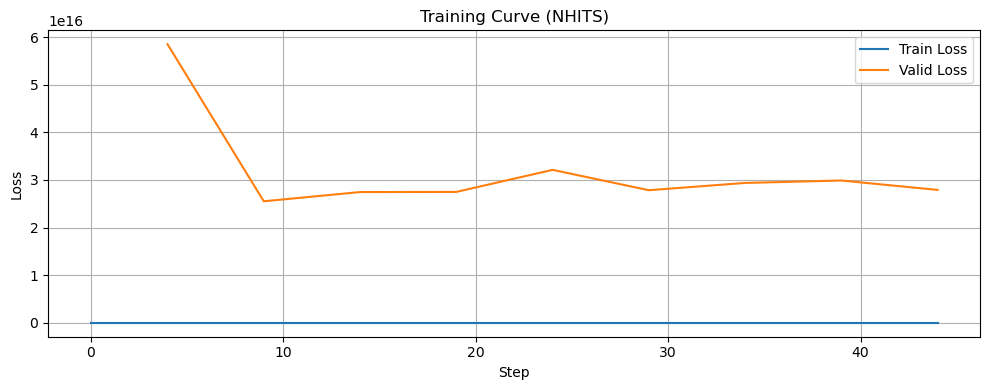

Seed set to 2026


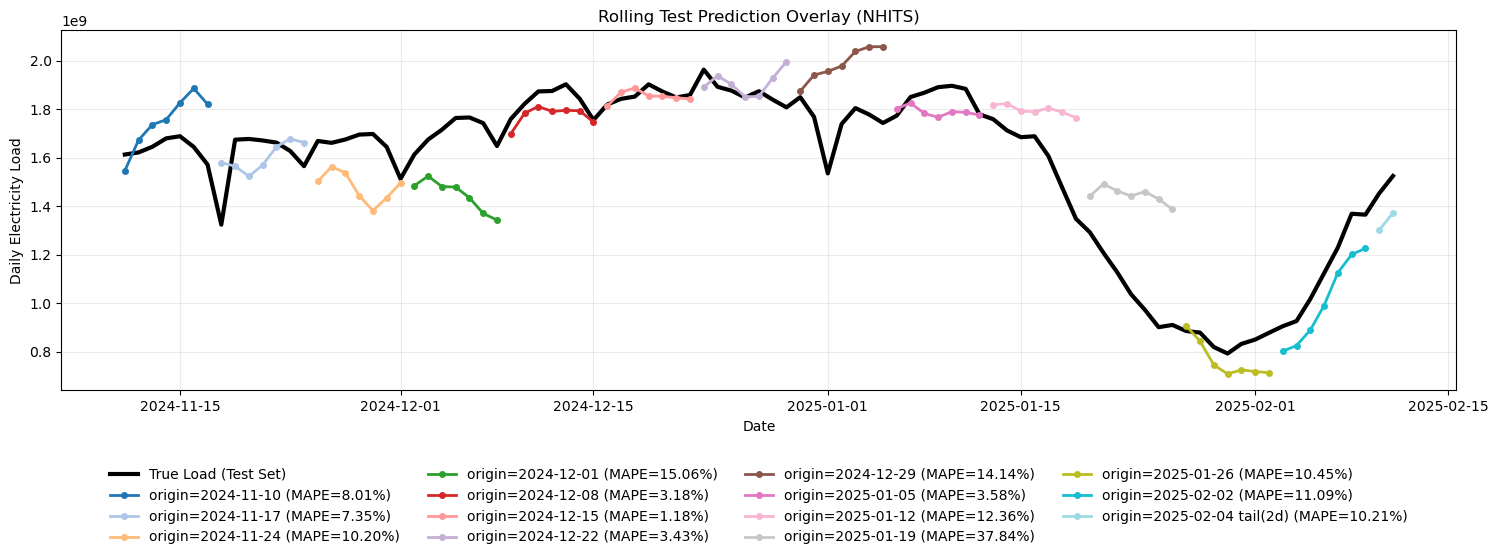

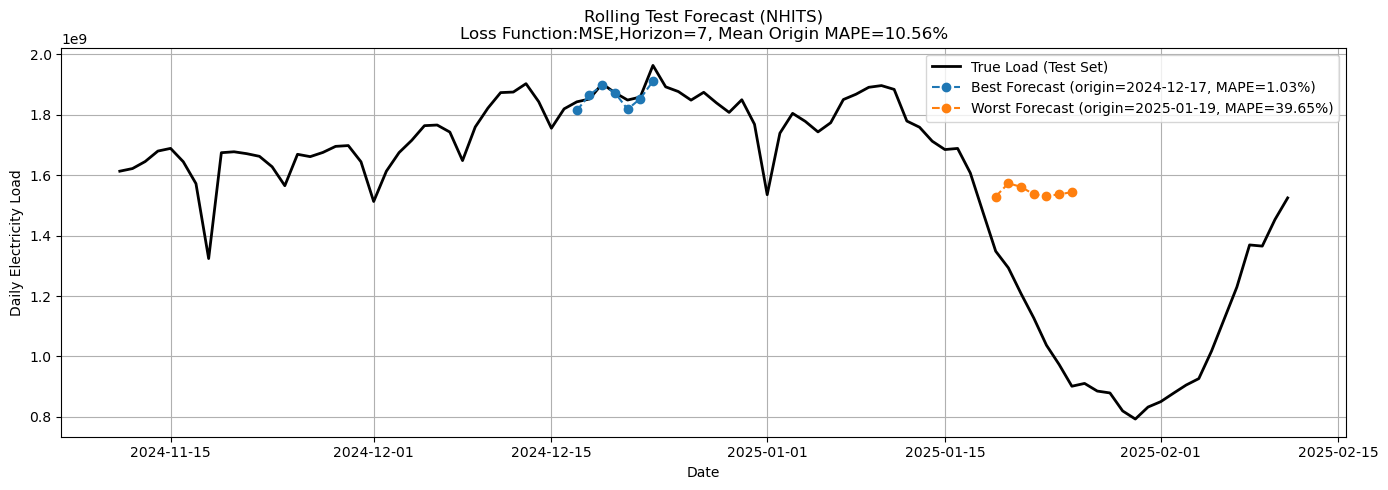

{'model_name': 'NHITS', 'val_overall_mape': 7.916509552892711, 'overall_mape': 10.563230050101225, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\NHITS_no_feat\\20260415_174311', 'best_model_path': 'artifacts\\NHITS_no_feat\\20260415_174311\\checkpoints\\final.ckpt', 'rolling_raw_path': 'artifacts\\NHITS_no_feat\\20260415_174311\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\NHITS_no_feat\\20260415_174311\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\NHITS_no_feat\20260415_174311\rolling_test_raw.csv


In [3]:
from neuralforecast.models import NHITS

nhits_spec = ModelSpec(
    name='NHITS',
    model_type='neural',
    model_cls=NHITS,
    model_params={
        'max_steps': 100,
        'learning_rate': 1e-3,
        'scaler_type': 'standard',
    },
    supports_future_exog=True,
)

nhits_result = runner.run(nhits_spec)
print(nhits_result.summary())
print(f"rolling_raw_path: {nhits_result.rolling_raw_path}")


Seed set to 2026
Seed set to 2026


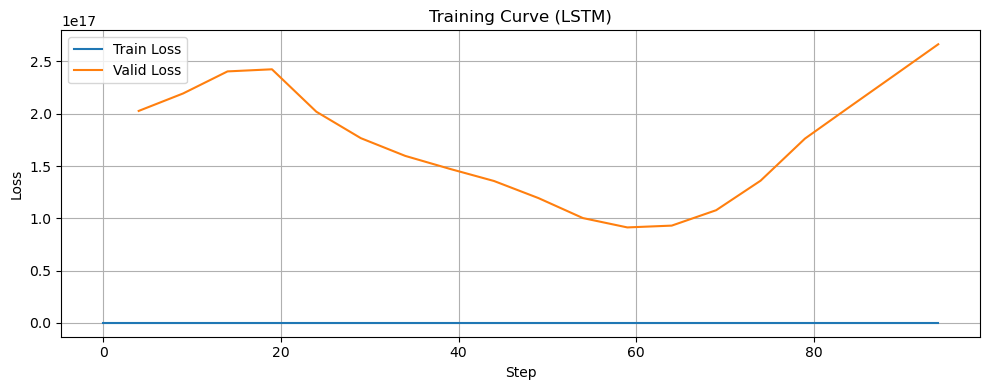

Seed set to 2026


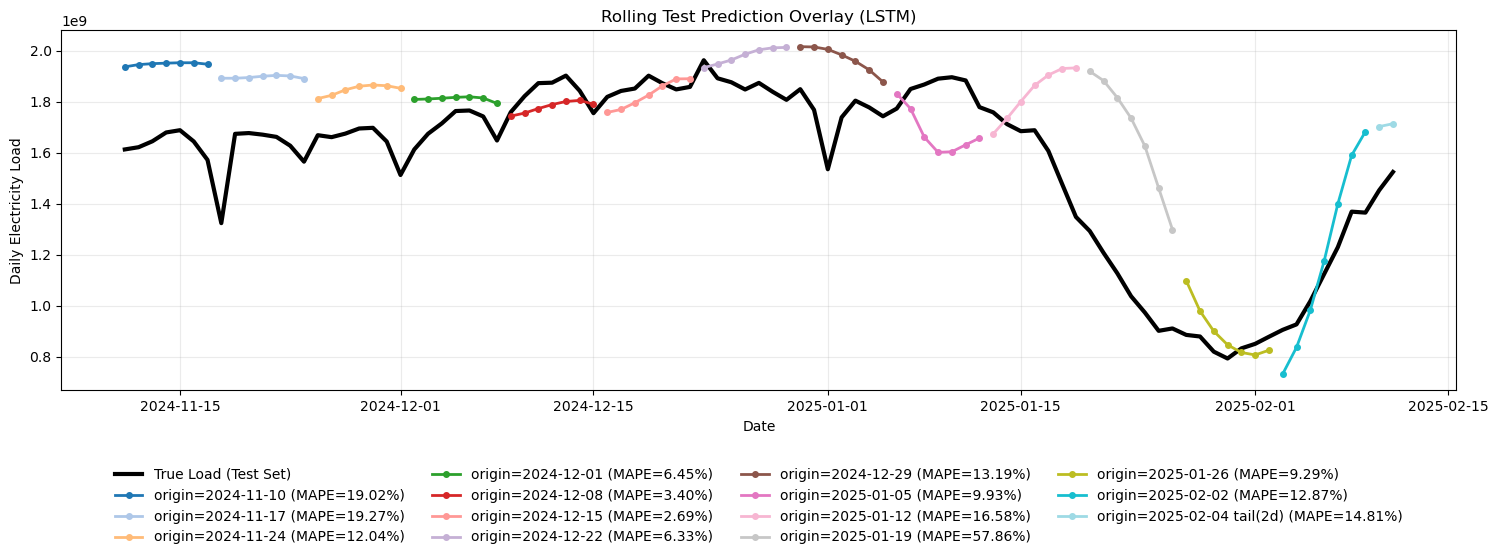

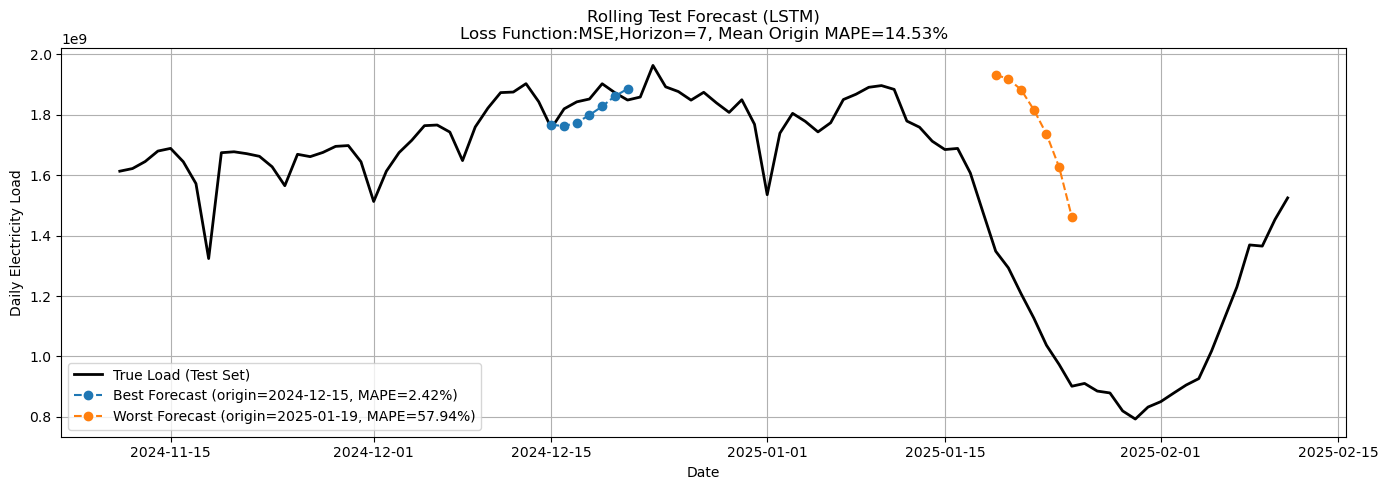

{'model_name': 'LSTM', 'val_overall_mape': 31.833201793813746, 'overall_mape': 14.526742608041681, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\LSTM_no_feat\\20260415_174347', 'best_model_path': 'artifacts\\LSTM_no_feat\\20260415_174347\\checkpoints\\final.ckpt', 'rolling_raw_path': 'artifacts\\LSTM_no_feat\\20260415_174347\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\LSTM_no_feat\\20260415_174347\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\LSTM_no_feat\20260415_174347\rolling_test_raw.csv


In [4]:
from neuralforecast.models import LSTM

lstm_spec = ModelSpec(
    name='LSTM',
    model_type='neural',
    model_cls=LSTM,
    model_params={
        'encoder_hidden_size': 64,
        'encoder_n_layers': 2,
        'encoder_dropout': 0.1,
        'decoder_hidden_size': 64,
        'decoder_layers': 2,
        'max_steps': 100,
        'learning_rate': 1e-3,
        'scaler_type': 'standard',
    },
    supports_future_exog=True,
)

lstm_result = runner.run(lstm_spec)
print(lstm_result.summary())
print(f"rolling_raw_path: {lstm_result.rolling_raw_path}")


Seed set to 2026


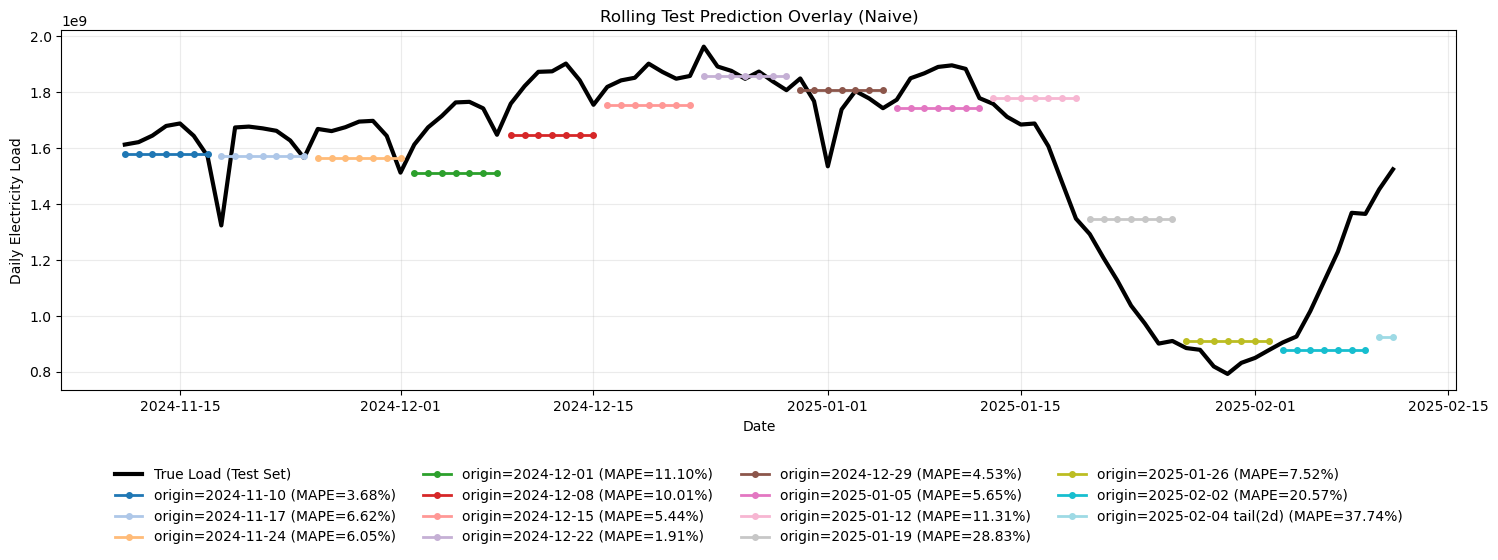

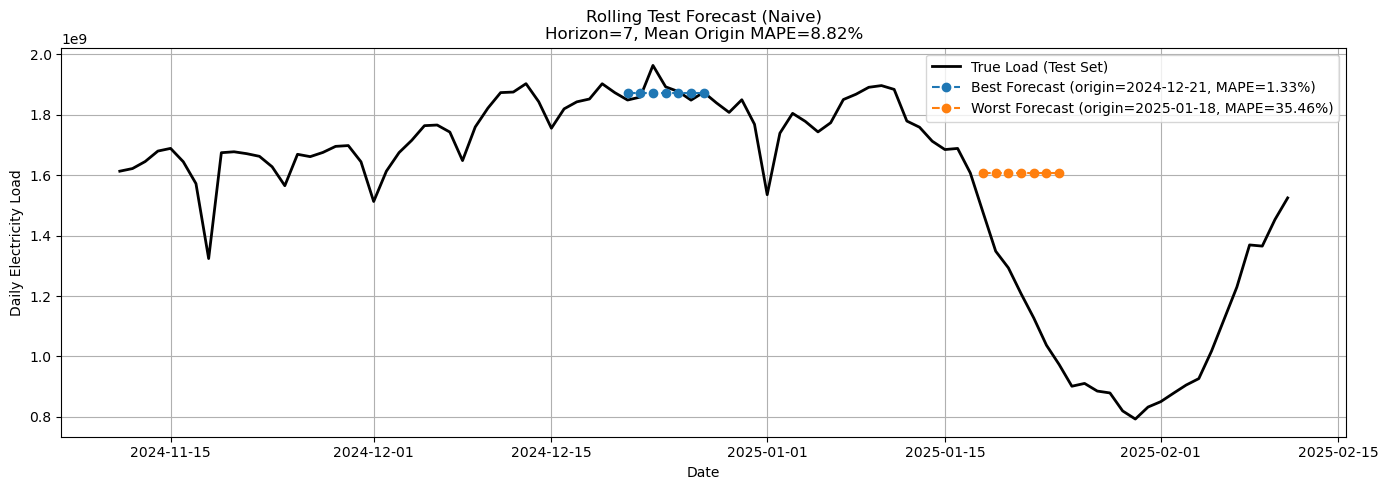

{'model_name': 'Naive', 'val_overall_mape': 7.798298665691358, 'overall_mape': 8.820472000008197, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\Naive_no_feat\\20260415_174413', 'best_model_path': None, 'rolling_raw_path': 'artifacts\\Naive_no_feat\\20260415_174413\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\Naive_no_feat\\20260415_174413\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\Naive_no_feat\20260415_174413\rolling_test_raw.csv


In [5]:
from statsforecast.models import Naive

naive_spec = ModelSpec(
    name='Naive',
    model_type='stats',
    model_cls=Naive,
    model_params={},
)

naive_result = runner.run(naive_spec)
print(naive_result.summary())
print(f"rolling_raw_path: {naive_result.rolling_raw_path}")


Seed set to 2026
Seed set to 2026


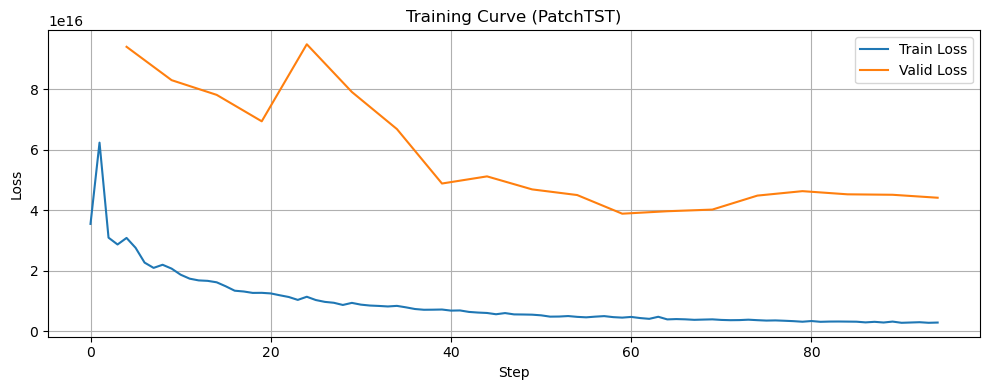

Seed set to 2026


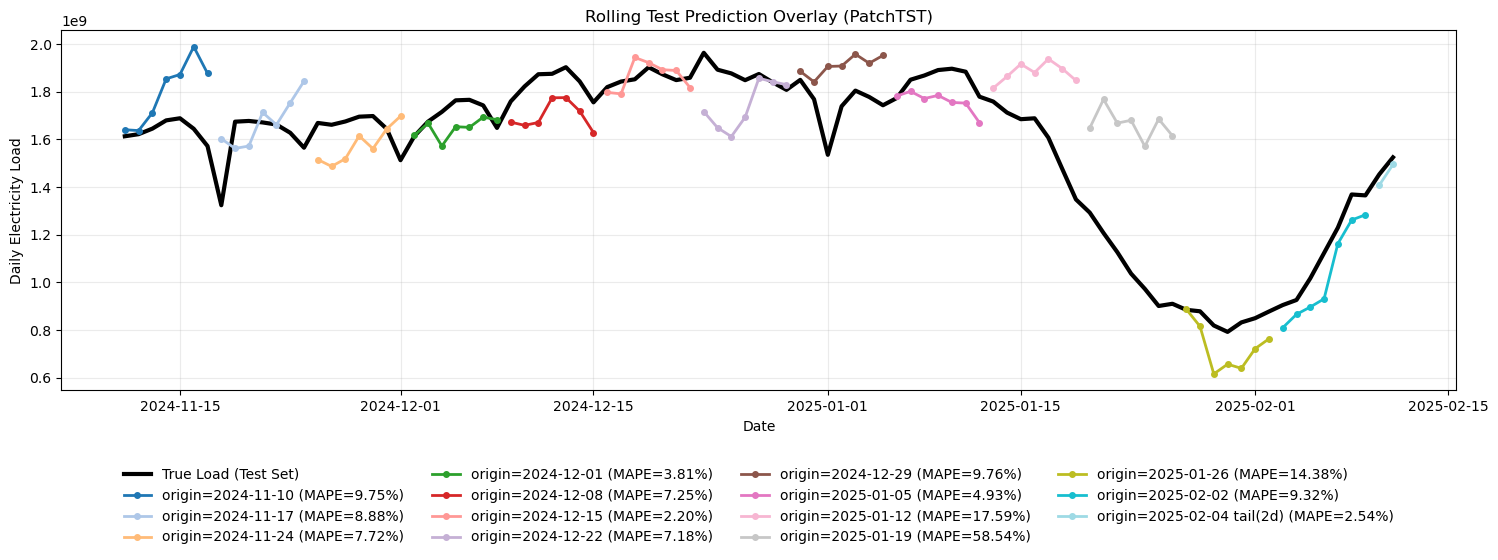

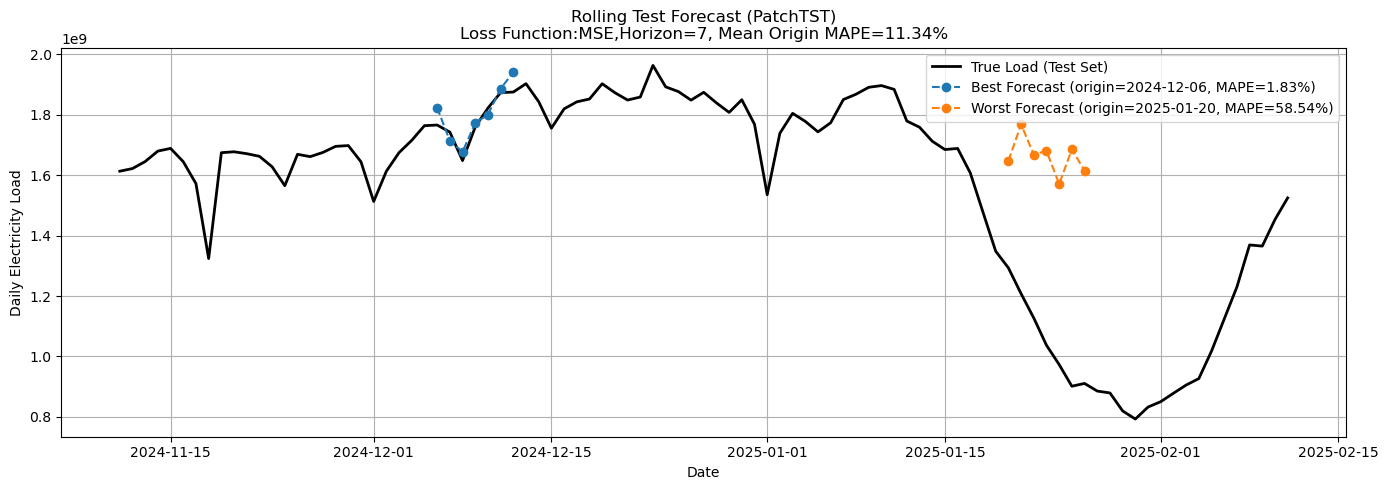

{'model_name': 'PatchTST', 'val_overall_mape': 9.887081502974665, 'overall_mape': 11.342454904964729, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\PatchTST_no_feat\\20260415_174416', 'best_model_path': 'artifacts\\PatchTST_no_feat\\20260415_174416\\checkpoints\\final.ckpt', 'rolling_raw_path': 'artifacts\\PatchTST_no_feat\\20260415_174416\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\PatchTST_no_feat\\20260415_174416\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\PatchTST_no_feat\20260415_174416\rolling_test_raw.csv


In [6]:
from neuralforecast.models import PatchTST

# PatchTST does not support historical or future exogenous variables in this repo.
# If USE_HIST_EXOG=True or USE_FUTR_EXOG=True, rerun the setup cell with both set to False before training PatchTST.
patchtst_spec = ModelSpec(
    name='PatchTST',
    model_type='neural',
    model_cls=PatchTST,
    model_params={
        'n_heads': 4,
        'hidden_size': 128,
        'dropout': 0.1,
        'max_steps': 100,
        'learning_rate': 1e-3,
    },
    supports_hist_exog=False,
    supports_future_exog=False,
)

patchtst_result = runner.run(patchtst_spec)
print(patchtst_result.summary())
print(f"rolling_raw_path: {patchtst_result.rolling_raw_path}")


Seed set to 2026
d:\miniconda\envs\dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000751 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7488
[LightGBM] [Info] Number of data points in the train set: 231, number of used features: 96
[LightGBM] [Info] Start training from score 1803428891.151515
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

d:\miniconda\envs\dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\miniconda\envs\dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\miniconda\envs\dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\miniconda\envs\dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\miniconda\envs\dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\miniconda\envs\dl\Lib\site-packages\sklearn\utils\validat

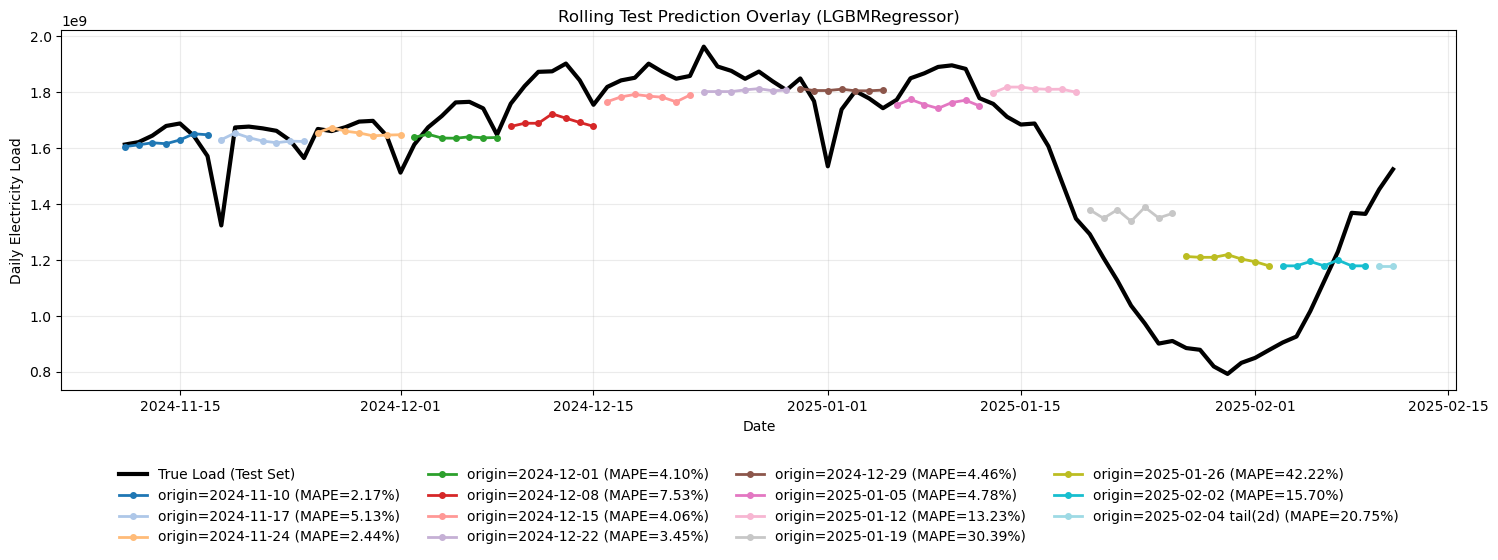

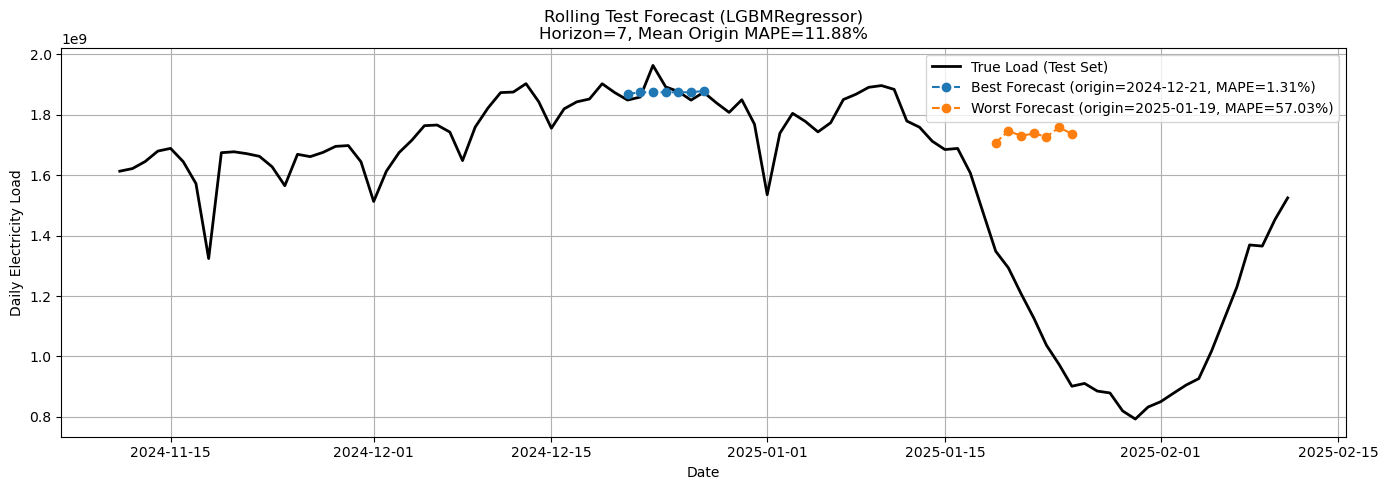

{'model_name': 'LGBMRegressor', 'val_overall_mape': 6.313006612829016, 'overall_mape': 11.877749832486622, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\LGBMRegressor_no_feat\\20260415_174456', 'best_model_path': None, 'rolling_raw_path': 'artifacts\\LGBMRegressor_no_feat\\20260415_174456\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\LGBMRegressor_no_feat\\20260415_174456\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\LGBMRegressor_no_feat\20260415_174456\rolling_test_raw.csv


In [7]:
from lightgbm import LGBMRegressor

lgbm_spec = ModelSpec(
    name='LGBMRegressor',
    model_type='ml',
    model_cls=LGBMRegressor,
    model_params={
        'n_estimators': 200,
        'random_state': RANDOM_SEED,
    },
    supports_future_exog=True,
)

lgbm_result = runner.run(lgbm_spec)
print(lgbm_result.summary())
print(f"rolling_raw_path: {lgbm_result.rolling_raw_path}")


In [8]:
# from neuralforecast.models import TimeLLM

# # TimeLLM requires `transformers`.
# # It does not support historical or future exogenous variables in this repo.
# # If USE_HIST_EXOG=True or USE_FUTR_EXOG=True, rerun the setup cell with both set to False before training TimeLLM.
# timellm_spec = ModelSpec(
#     name='TimeLLM',
#     model_type='neural',
#     model_cls=TimeLLM,
#     model_params={
#         'llm': 'openai-community/gpt2',
#         'max_steps': 5,
#         'learning_rate': 1e-4,
#         'batch_size': 1,
#         'scaler_type': 'identity',
#         'prompt_prefix': 'Forecast the next daily electricity load values.',
#     },
#     supports_hist_exog=False,
#     supports_future_exog=False,
# )

# timellm_result = runner.run(timellm_spec)
# print(timellm_result.summary())
# print(f"rolling_raw_path: {timellm_result.rolling_raw_path}")
